### Загрузка и обработка данных

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import arch.unitroot as au
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.tsa.ardl import ARDL, ardl_select_order
import sys
import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
import itertools
import math
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy.stats import chi2, f
from statsmodels.tsa.x13 import x13_arima_analysis
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, globalenv
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects.conversion import localconverter
import rpy2.rinterface_lib.callbacks
import os
import pickle
from statsmodels.tsa.x13 import x13_arima_analysis
import tempfile
import uuid
from typing import Dict, List, Tuple
import re

import panel_utils
from panel_utils import (
    detect_outlier_regions_iqr,
    friedman_seasonality_test,
    run_panel_unit_root_tests,
    seasonal_adjust_panel_series,
    run_friedman_seasonality_tests,
)


In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')
households_structure = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')
pickle_filename = 'region_cluster_dataset.pkl'
# df_roisfix = pd.read_excel('roisfix.xlsx') # скорректированный ROISFIX из Тейлора
# df_roisfix = df_roisfix.drop(columns=['Unnamed: 0'])
with open(pickle_filename, 'rb') as f:
    df_region_cluster = pickle.load(f)

# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [3]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'rb') as f:
    df_shocks = pickle.load(f)
df_shocks['Date'] = pd.to_datetime(df_shocks['Date'])

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

df_reg['Date'] = pd.to_datetime(df_reg['Date'])

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster, on='Region', how='left')

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')

df_rf_extra = df_RF[['Date', 'Bonds_Rate_Correct_5Y', 'Inflation_Expectations', 'exc_rate', 'MIACR', 'Covid_dum', 'Sank_dum', 'ROISFIX']].copy()
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'exc_rate': 'Exc_rate'}, inplace=True)

# Создаем лаги
df_reg['Int_Rate_FL_lag1'] = df_reg.groupby('Region')['Int_Rate_FL'].shift(1)
df_reg['Int_Rate_Mort_lag1'] = df_reg.groupby('Region')['Int_Rate_Mort'].shift(1)
df_reg['Int_Rate_ConsCred_lag1'] = df_reg.groupby('Region')['Int_Rate_ConsCred'].shift(1)

# СПИСОК ПЕРЕМЕННЫХ
initial_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'MIACR',
    'Covid_dum',
    'Sank_dum',
    'ROISFIX'
]

df_reg_analys = df_reg[['Region', 'Date'] + initial_vars].copy()
df_reg_analys = df_reg_analys[df_reg_analys['Region'] != 'Москва']
cols_for_drop = [c for c in df_reg_analys.columns if c not in ['New_Loans_Progr']]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

### IQR чистка

In [4]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'
]



# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")





ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 85 РЕГИОНОВ (IQR)
                                              Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
                                Белгородская область     78   0.0%             4    5.1%                                  KEEP
                                    Брянская область     78   0.0%             4    5.1%                                  KEEP
                                Владимирская область     78   0.0%             4    5.1%                                  KEEP
                                 Воронежская область     78   0.0%             4    5.1%                                  KEEP
                                  Ивановская область     78   0.0%             3    3.8%                                  KEEP
                                    Тверская область     78   0.0%             3    3.8%                                  KEEP
                                   Калужская область

### ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ

In [5]:
descriptive_df = df_reg_analys[[
    'Int_Rate_FL',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_ConsCred',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'Covid_dum',
    'Sank_dum'
]]
desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                            Среднее     Медиана    ст. откл.     Мин.  \
Int_Rate_FL                  14.231      13.163        3.448    9.100   
Int_Rate_Mort                 8.245       8.061        1.334    3.327   
Credit_impulse               -0.646      -0.171        6.504  -59.204   
Int_Rate_ConsCred            18.036      15.876        5.667   -8.170   
Cred_nagr                     0.352       0.356        0.084    0.072   
D_top5_rozn                   0.784       0.781        0.063    0.614   
Fin_Dostup                   19.221      18.651        6.003    2.972   
Cred_structure                0.467       0.470        0.065    0.147   
Def_Zadolg_Fl                 4.247       4.189        1.123    1.407   
Def_Zadolg_Mort               0.618       0.474        0.514    0.043   
Def_Zadolg_ConsCred           7.445       7.444        1.556    2.154   
Mon_Shock                    -0.005      -0.136        1.477   -4.416  

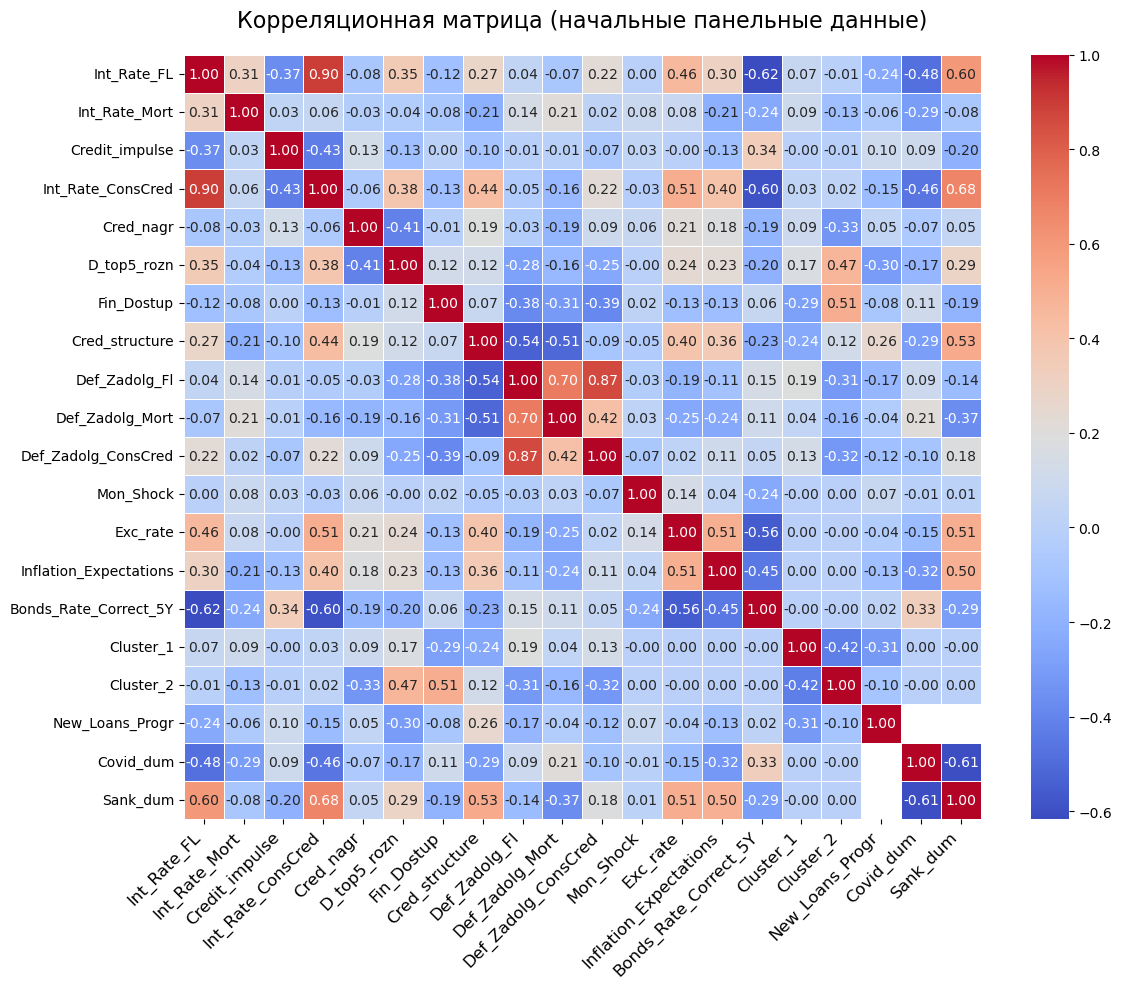

In [6]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

### Мультиколлинеарность

In [7]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 1
###############################

vif_variables = [
    'Int_Rate_FL_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1
              Variable      VIF
              Sank_dum 3.770883
 Bonds_Rate_Correct_5Y 3.307266
      Int_Rate_FL_lag1 3.077582
           D_top5_rozn 2.723955
              Exc_rate 2.675226
             Cluster_2 2.570506
        Cred_structure 2.374616
         Def_Zadolg_Fl 2.179367
             Covid_dum 2.148277
Inflation_Expectations 1.846656
             Cluster_1 1.788234
             Cred_nagr 1.782442
            Fin_Dostup 1.753097
        Credit_impulse 1.484894
             Mon_Shock 1.120207


In [8]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 2
###############################

vif_variables = [
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2
              Variable      VIF
              Sank_dum 3.929633
Int_Rate_ConsCred_lag1 3.630197
 Bonds_Rate_Correct_5Y 3.207145
           D_top5_rozn 2.789691
              Exc_rate 2.659576
             Cluster_2 2.554253
             Covid_dum 2.111859
        Cred_structure 1.858687
             Cluster_1 1.793780
             Cred_nagr 1.772630
Inflation_Expectations 1.751711
            Fin_Dostup 1.675020
   Def_Zadolg_ConsCred 1.658112
        Credit_impulse 1.517347
             Mon_Shock 1.142269


In [9]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 3
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3
              Variable      VIF
              Sank_dum 3.637825
              Exc_rate 2.895542
             Covid_dum 2.719557
 Bonds_Rate_Correct_5Y 2.597287
             Cluster_2 2.530489
           D_top5_rozn 2.467424
Inflation_Expectations 1.975593
        Cred_structure 1.963065
             Cluster_1 1.829058
    Int_Rate_Mort_lag1 1.819949
            Fin_Dostup 1.788989
       Def_Zadolg_Mort 1.737599
             Cred_nagr 1.732449
        Credit_impulse 1.469290
             Mon_Shock 1.108694


In [10]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 4
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'New_Loans_Progr',
    'Cluster_1',
    'Cluster_2',
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 4
              Variable      VIF
 Bonds_Rate_Correct_5Y 3.389993
              Exc_rate 3.129117
             Cluster_2 2.723775
           D_top5_rozn 2.501686
             Cluster_1 2.078529
            Fin_Dostup 1.912779
       Def_Zadolg_Mort 1.890889
    Int_Rate_Mort_lag1 1.784732
             Cred_nagr 1.766992
Inflation_Expectations 1.701798
        Credit_impulse 1.679744
        Cred_structure 1.492804
             Mon_Shock 1.397599
       New_Loans_Progr 1.301347


### Тест Фридмана на сезонность

In [11]:
friedman_summary = panel_utils.run_friedman_seasonality_tests(df_RF, date_col='Date')



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                  Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
                   Num_reg          NaN      NaN            False        5        12
             CAR_Indicator    12.107692 0.355603            False        5        12
              D_Progr_mort    11.707692 0.386011            False        5        12
                   ROISFIX     4.456963 0.954598            False        5        12
                  exc_rate    15.276923 0.170167            False        5        12
             exc_rate_diff    17.892308 0.084113            False        5        12
     Bonds_Rate_Correct_5Y     3.800000 0.975406            False        5        12
    Inflation_Expectations    21.442254 0.029068             True        5        12
      Nominal_Percent_Rate    11.863422 0.373996            False        5        12
       Ent_conf_ind_mining    21.098503 0.032365             True        5        12
Ent_conf_ind_manufactoring    27.5839

c:\Users\donat\anaconda3\envs\Credit\Lib\site-packages\scipy\stats\_stats_py.py:8780: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c


In [12]:
# # Extra diagnostics after Friedman test
# from panel_utils import run_seasonal_diagnostics

# series_list = [
#     'Inflation_Expectations',
#     'Ent_conf_ind_mining',
#     'Ent_conf_ind_manufactoring'
# ]


# for col in series_list:
#     if col in df_RF.columns:
#         run_seasonal_diagnostics(df_RF, 'Date', col, shock_year="2022")
#     else:
#         print(f'Missing column: {col}')


# ####################################
# # Сезонность есть даже с учётом шока в: Inflation_Expectations, Ent_conf_ind_manufactoring

### ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====


СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Инфляционные ожидания (Inflation_Expectations):
  ✓ Успешно скорректировано, снижение волатильности: 2.5%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ
✓ Inflation_Expectations_adj: 6318 не-NaN значений
✓ Inflation_Expectations_trend: 6318 не-NaN значений
✓ Inflation_Expectations_seasonal: 6318 не-NaN значений

✓ Всего добавлено столбцов: 3

СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКТИРОВКИ

Федеральные переменные:
--------------------------------------------------
Переменная                     Волатильность ↓
--------------------------------------------------
Инфляционные ожидания                     2.5%


Региональные переменные (среднее по регионам):
--------------------------------------------------
Переменная                     Волатильность ↓
--------------------------------------------------

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ПРИМЕРЫ)

Графики федеральных переменных...


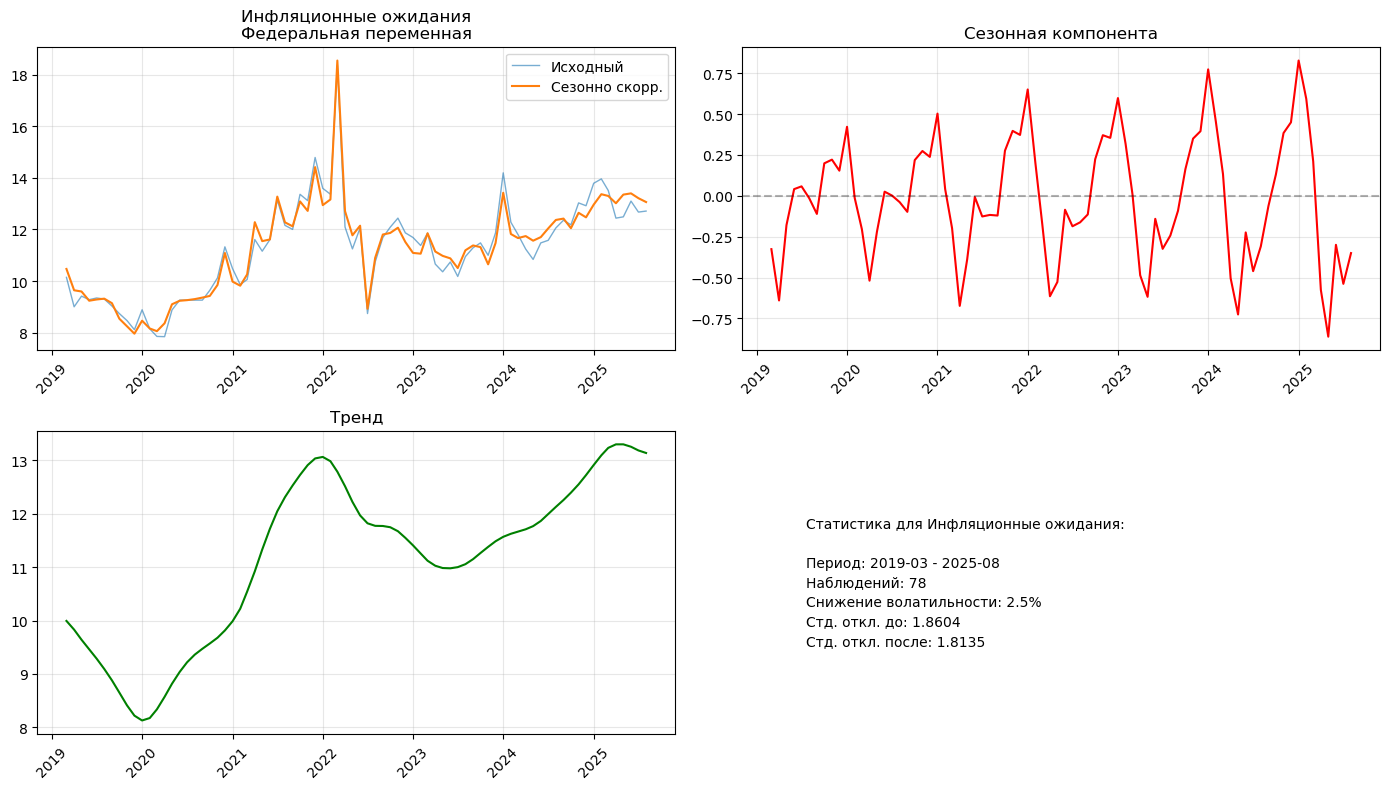


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 1/1
Обработано региональных переменных: 0/0
Общее количество добавленных столбцов: 3
Форма df: (6318, 30)

Столбцов _adj: 1
Столбцов _trend: 1
Столбцов _seasonal: 1

✓ Скорректированные ряды добавлены в df
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)

СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Ent_conf_ind_manufactoring (Ent_conf_ind_manufactoring):
  ✓ Успешно скорректировано, снижение волатильности: 5.8%

Ent_conf_ind_mining (Ent_conf_ind_mining):
  ✓ Успешно скорректировано, снижение волатильности: 8.6%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ
✓ Ent_conf_ind_manufactoring_adj: 81 не-NaN значений
✓ Ent_conf_ind_manufactoring_trend: 81 не-NaN значений
✓ Ent_conf_ind_manufactoring_seasonal: 81 не-NaN значений
✓ Ent_conf_ind_mining_adj: 81 не-NaN значений
✓ Ent_conf_ind_mining_trend: 81 не-NaN значений
✓ Ent_conf_ind_mining_seasonal: 81 не-NaN значений

✓ Всего

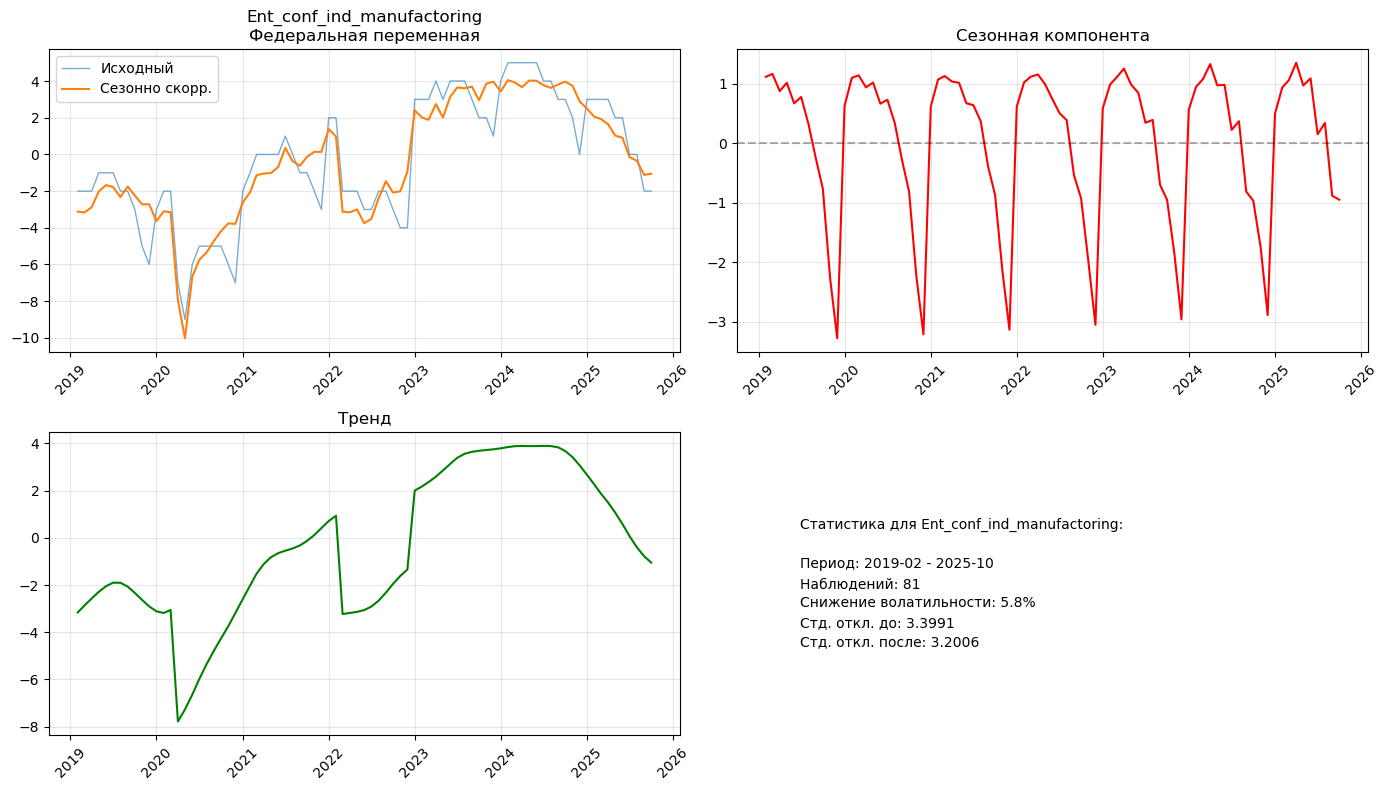

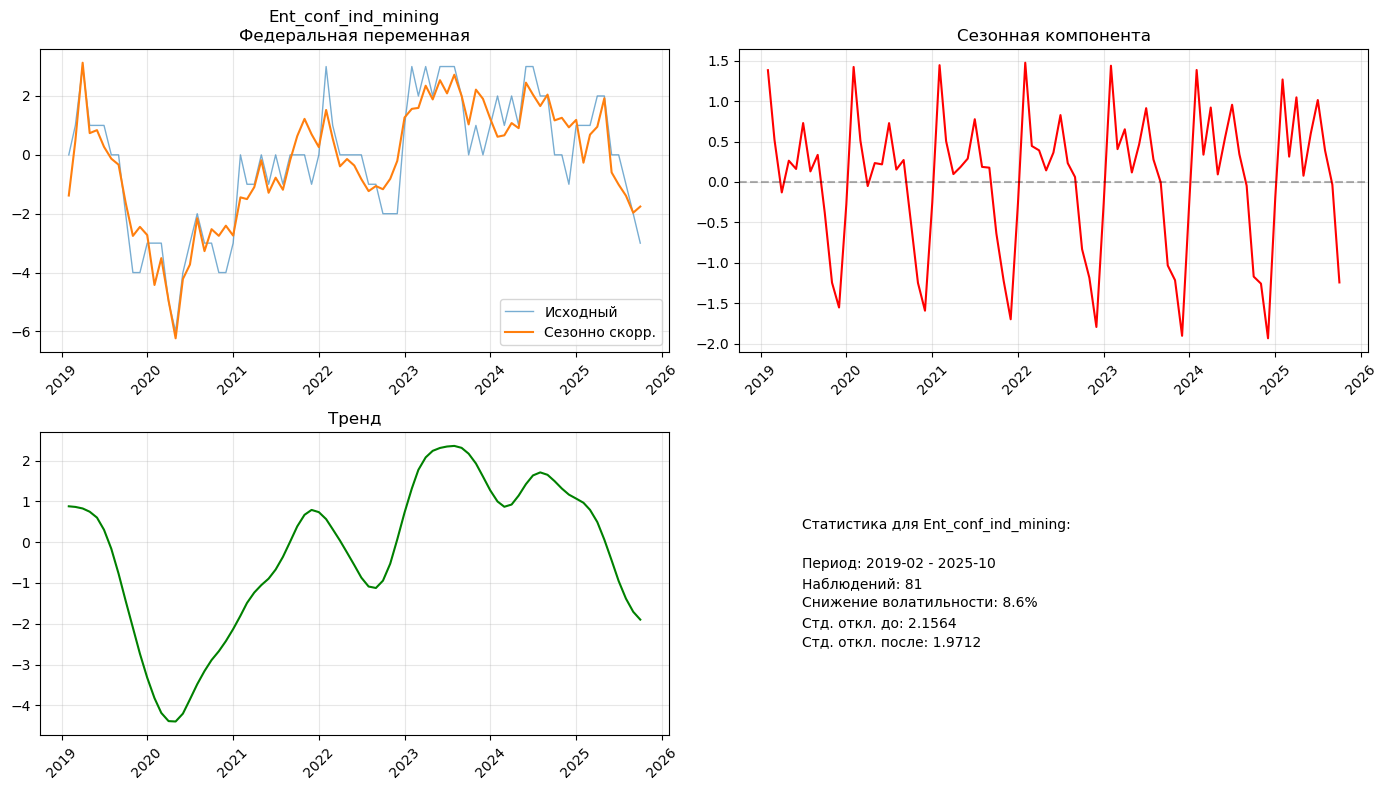


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 2/2
Обработано региональных переменных: 0/0
Общее количество добавленных столбцов: 6
Форма df: (81, 23)

Столбцов _adj: 2
Столбцов _trend: 2
Столбцов _seasonal: 2

✓ Скорректированные ряды добавлены в df
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)


In [13]:
# Сезонная корректировка 
# 'Inflation_Expectations', 'Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining' потенциальные переменные

from seasonal_adjustment import seasonal_adjust_panel_wrapper

col_name = ['Inflation_Expectations'] 
df_reg_analys = seasonal_adjust_panel_wrapper(df_reg_analys, col_name)

col_name = ['Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining'] 
df_RF = seasonal_adjust_panel_wrapper(df_RF, col_name)


In [14]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6318 entries, 0 to 6317
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Region                           6318 non-null   object        
 1   Date                             6318 non-null   datetime64[ns]
 2   Int_Rate_FL                      6318 non-null   float64       
 3   Int_Rate_FL_lag1                 6318 non-null   float64       
 4   Int_Rate_Mort                    6318 non-null   float64       
 5   Credit_impulse                   6318 non-null   float64       
 6   Int_Rate_Mort_lag1               6318 non-null   float64       
 7   Int_Rate_ConsCred                6318 non-null   float64       
 8   Int_Rate_ConsCred_lag1           6318 non-null   float64       
 9   Cred_nagr                        6318 non-null   float64       
 10  D_top5_rozn                      6318 non-null   float64    

In [15]:
df_RF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Num_reg                              81 non-null     int64         
 1   Region                               81 non-null     object        
 2   Date                                 81 non-null     datetime64[ns]
 3   CAR_Indicator                        81 non-null     float64       
 4   D_Progr_mort                         81 non-null     float64       
 5   ROISFIX                              81 non-null     float64       
 6   exc_rate                             81 non-null     float64       
 7   exc_rate_diff                        81 non-null     float64       
 8   Bonds_Rate_Correct_5Y                81 non-null     float64       
 9   Inflation_Expectations               81 non-null     float64       
 10  Nominal_Percent_

In [16]:
df_reg_analys.to_excel('reg_analys.xlsx')
df_RF.to_excel('fed_analys.xlsx')
#df_reg_analys = pd.read_excel('reg_analys.xlsx')

In [ ]:
# ===== УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ =====

print("="*70)
print("УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ")
print("="*70)

print(f"\n ИСХОДНЫЕ ДАННЫЕ:")
print(f"Форма датасета: {df_reg_analys.shape}")
print(f"Всего столбцов: {len(df_reg_analys.columns)}")

# Определяем столбцы, которые оставляем:
# 1. 'Date' и 'Region' (служебные)
# 2. Все столбцы, заканчивающиеся на '_adj' 

columns_to_keep = ['Date', 'Region', 'Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']
adjusted_columns = [col for col in df_reg_analys.columns 
                   if col.endswith('_adj')]

columns_to_keep.extend(adjusted_columns)

print(f"\n СТОЛБЦЫ ДЛЯ СОХРАНЕНИЯ:")
print(f"Служебные: {['Date', 'Region']}")
print(f"+ {['Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']}")
print(f"Adjusted (_adj): {len([c for c in adjusted_columns if c.endswith('_adj')])} столбцов")

# Определяем столбцы на удаление
columns_to_drop = [col for col in df_reg_analys.columns if col not in columns_to_keep]

print(f"\n СТОЛБЦЫ НА УДАЛЕНИЕ:")
print(f"Всего на удаление: {len(columns_to_drop)}")
for i, col in enumerate(columns_to_drop, 1):
    print(f"  {i}. {col}")

# Удаляем столбцы
df_reg_analys = df_reg_analys.drop(columns=columns_to_drop)

print(f"\n" + "="*70)
print("ПОСЛЕ УДАЛЕНИЯ:")
print("="*70)
print(f"✓ Форма датасета: {df_reg_analys.shape}")
print(f"✓ Всего столбцов: {len(df_reg_analys.columns)}")

# Статистика по столбцам
adj_count = len([c for c in df_reg_analys.columns if c.endswith('_adj')])
trend_count = len([c for c in df_reg_analys.columns if c.endswith('_trend')])
seasonal_count = len([c for c in df_reg_analys.columns if c.endswith('_seasonal')])

## Tестирование единичных корней

In [ ]:
###########################################################
# Вспомогательные функции: KPSS, Hadri LM (panel), Levin–Lin–Chu (panel)
###########################################################





###########################################################
# Основная функция для тестирования единичных корней
###########################################################



# ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1")
print("="*70)

# === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
custom_vars = [
    'Int_Rate_FL_adj',
    'Int_Rate_FL_lag1_adj',
    'Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'Int_Rate_Mort_lag1_adj',
    'Int_Rate_ConsCred_adj',
    'Int_Rate_ConsCred_lag1_adj',
    'Cred_nagr_adj',
    'D_top5_rozn_adj',
    'Fin_Dostup_adj',
    'Cred_structure_adj',
    'Def_Zadolg_Fl_adj',
    'Def_Zadolg_Mort_adj',
    'Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'Bonds_Rate_Correct_5Y_adj',
    'Exc_rate_adj',
    'MIACR',
    'New_Loans_Progr'
]
df_reg_analys_clus_1 = df_reg_analys[df_reg_analys['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_1, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2")
print("="*70)


df_reg_analys_clus_two = df_reg_analys[df_reg_analys['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_two, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3")
print("="*70)

df_reg_analys_clus_three = df_reg_analys[(df_reg_analys['Cluster_1'] == 0) & (df_reg_analys['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_three, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted_all = run_panel_unit_root_tests(df_reg_analys, panel_vars=custom_vars)

### Переход к первым разностям панельных данных
### С логарифмированием переменных выдач

In [ ]:
###############################
# Переход к первым разностям панельных данных
# С логарифмированием переменных выдач
###############################
df_reg = df_reg_analys.copy()

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

# ============ ЛОГАРИФМИРОВАНИЕ ВЫДАЧ ============

loan_vars = ['New_Loans_Fl_adj', 'New_Loans_Mort_adj', 'New_Loans_ConsCred_adj', 'MIACR', 'New_Loans_Progr']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ ТОЛЬКО ДЛЯ НЕСТАЦИОНАРНЫХ ПЕРЕМЕННЫХ ============

exclude_cols = ['Region', 'Date']

# список скорректированных переменных, для которых тесты показали нестационарность
nonstat_vars = results_seasonal_adjusted.loc[
    results_seasonal_adjusted['Overall_Stationarity'] == False,  # нестационарные
    'Переменная'].tolist()

# защитимся от случая, если в results есть переменные, которых уже нет в df_reg
nonstat_vars = [v for v in nonstat_vars if v in df_reg.columns]

# логарифмы выдач
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# обычные переменные, для которых нужно строить разности:
#  - только нестационарные
#  - исключаем служебные, логарифмы и уже существующие d_
initial_vars = [
    col for col in nonstat_vars
    if col not in exclude_cols
    and not col.startswith('d_')
    and not col.startswith('ln_')
]

# Разности для обычных нестационарных переменных
for var in initial_vars:
    df_reg[f'd_{var}'] = df_reg.groupby('Region')[var].diff()

# Разности для логарифмов выдач (их всегда дифференцируем, как раньше)
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

# ============ ПРОВЕРКА СОЗДАННЫХ СТОЛБЦОВ ============

d_cols = [col for col in df_reg.columns if col.startswith('d_')]

exog_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj', 
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'ln_New_Loans_Progr',
    'd_ln_MIACR',
    'Covid_dum',
    'Sank_dum',
    'd_ln_ROISFIX'
]

# Проверяем, какие переменные реально существуют
exog_vars_existing = [var for var in exog_vars if var in df_reg.columns]
exog_vars_missing = [var for var in exog_vars if var not in df_reg.columns]

df_exog = df_reg[['Region', 'Date'] + exog_vars_existing].copy()
cols_to_check = [c for c in df_exog.columns if c != 'ln_New_Loans_Progr']
df_exog = df_exog.dropna(subset=cols_to_check)

In [ ]:
df_exog.head()

In [ ]:
df_exog.info()

In [ ]:
#df_exog.to_excel('exog.xlsx')

In [ ]:
#df_exog = pd.read_excel('exog.xlsx')

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',  
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'Covid_dum',
    'Sank_dum',
    'ln_New_Loans_Progr'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
    #Добавление дополнительных переменных
###############################

# Кластеры * монетарный шок
df_exog['Mon_Shock_Cl1'] = df_exog['Mon_Shock'] * df_exog['Cluster_1']
df_exog['Mon_Shock_Cl2'] = df_exog['Mon_Shock'] * df_exog['Cluster_2']

# Кластеры * d_ln_ROISFIX
df_exog['d_ln_ROISFIX_Cl1'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_1']
df_exog['d_ln_ROISFIX_Cl2'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_2']

# Кластеры * d_ln_MIACR
df_exog['d_ln_MIACR_Cl1'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_1']
df_exog['d_ln_MIACR_Cl2'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_2']

# Covid * переменные интреса
df_exog['Mon_Shock_Covid']   = df_exog['Mon_Shock']   * df_exog['Covid_dum']
df_exog['d_ln_ROISFIX_Covid'] = df_exog['d_ln_ROISFIX'] * df_exog['Covid_dum']
df_exog['d_ln_MIACR_Covid']   = df_exog['d_ln_MIACR']   * df_exog['Covid_dum']

# Санкции * переменные интреса
df_exog['Mon_Shock_Sanctions']   = df_exog['Mon_Shock']   * df_exog['Sank_dum']
df_exog['d_ln_ROISFIX_Sanctions'] = df_exog['d_ln_ROISFIX'] * df_exog['Sank_dum']
df_exog['d_ln_MIACR_Sanctions']   = df_exog['d_ln_MIACR']   * df_exog['Sank_dum']


In [ ]:
df_exog.info()

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 4 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 5 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 5")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 6 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 6")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 7 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 7")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 8 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 8")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 9 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 9")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 10 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'

]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 11 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #Тест на стационарность I(1) рядов для 1-го кластера
###############################

custom_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj'
]
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 1")
print("="*70)

df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_one, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 2")
print("="*70)

df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_two, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 3")
print("="*70)

df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_three, panel_vars=custom_vars)

In [ ]:
df_exog_clus_one.info()

In [ ]:
df_exog_clus_two.info()

In [ ]:
df_exog_clus_three.info()